# Student Feedback Analysis

Notebook to evaluate anonymized student data.

### Goals
1. Summarize the factors that students found more surprising about the programs, and make a tally of the students mentioning each of those factors.
2. Summarize the factors that make the programs appealing to students, and make a tally of the students mentioning each of these factors.
3. Summarize the concerns that students have about the programs, and make a tally of students mentioning these concerns.
4. Make an estimation of how favorable / unfavorable students are towards these programs.

### Imports

In [170]:
from pathlib import Path
from docx import Document
import pdfplumber
import json, re
import boto3
import random
import pandas as pd
import matplotlib.pyplot as plt

### Preprocessing

In [22]:
OPS_FOLDERS = [
    Path("data/NRES 103 OPS and MGMT Careers Reflections - Anonymized"),
    Path("data/NRES 103 OPS and MGMT Reflections - Anonymized"),
]

docx_files = []
pdf_files = []

for folder in OPS_FOLDERS:
    docx_files.extend(folder.rglob("*.docx"))
    pdf_files.extend(folder.rglob("*.pdf"))

len(docx_files), len(pdf_files)

(179, 147)

In [6]:
# for docx files 
def extract_docx_text(path: Path) -> str:
    doc = Document(str(path))
    lines = []
    for p in doc.paragraphs:
        t = (p.text or "").strip()
        if t:
            lines.append(t)
    return "\n".join(lines).strip()

In [7]:
# for pdf files
def extract_pdf_text(path: Path) -> str:
    pages = []
    with pdfplumber.open(str(path)) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text:
                pages.append(text.strip())
    return "\n".join(pages).strip()

In [23]:
def clean_text(t: str) -> str:
    t = t.replace("\r\n", "\n").replace("\r", "\n")
    t = re.sub(r"[ \t]+", " ", t)
    t = re.sub(r"\n{3,}", "\n\n", t)
    return t.strip()


records = []

# Process DOCX files
for fp in docx_files:
    text = extract_docx_text(fp)
    text = clean_text(text)
    records.append({
        "file": str(fp),
        "ext": ".docx",
        "text": text,
        "n_chars": len(text),
    })

# Process PDF files
for fp in pdf_files:
    text = extract_pdf_text(fp)
    text = clean_text(text)
    records.append({
        "file": str(fp),
        "ext": ".pdf",
        "text": text,
        "n_chars": len(text),
    })

len(records), records[0]["n_chars"]

(326, 1838)

### LLM Analysis Approach

Use a **Map–Reduce style workflow** to analyze the student reflections.  
In this setup, the **map step processes each reflection independently**, while the **reduce step aggregates the results across all reflections**.

#### Step 1 - Theme Discovery (Codebook Creation)
First, the LLM analyzes a sample of extracted phrases from the reflections to identify the main **themes** students mention.  
These themes are organized into three categories:
- **Appealing factors**
- **Concerns**
- **Surprising factors**

The resulting themes form a **codebook** that will be used to categorize reflections in the next step.

#### Step 2 - Map: Theme Assignment per Reflection
Next, the LLM processes each student reflection individually and assigns the relevant **theme IDs** from the codebook.  
Each reflection may be associated with **0–3 themes per category**.  
The LLM also assigns an **overall favorability score** for the program:

`<very_positive | positive | neutral | negative | very_negative>`

#### Step 3 - Reduce: Aggregation in Python
The results are aggregated in Python by counting how often each theme appears across reflections.  
This produces summary statistics such as:
- Frequency of each **appealing factor**, **concern**, and **surprising factor**
- Distribution of **overall favorability scores**

In [147]:
THEME_DISCOVERY_PROMPT = """
You are analyzing anonymized student reflections from a university course
about Forest Operations and Forest Management programs.

These reflections may include:
- Reactions to guest speakers and career pathways
- Comments about academic majors
- General reflections not directly structured as question answers

Important:
- Only analyze the student's response content.
- Ignore question text or instructions that appear in the document.
- Ignore student names or identifying information.
- Do not assume every category is mentioned.

Your task is to identify the most common **themes** in the reflections
and organize them into three categories:

1. Surprising Factors
   (things students learned that they did not expect)

2. Appealing Factors
   (things students liked about the program or careers)

3. Concerns
   (things students found worrying, difficult, or unappealing)

Instructions:
- For each category, produce **6-9 themes**.
- Themes should be **generalizable concepts**, not specific sentences.
- Use short descriptive labels (1-5 words).
- Avoid overlap between themes.
- Themes should be understandable to a non-technical reader.

Return ONLY valid JSON in this format:

{{
  "appealing_themes": [
    {{"id": "A1", "label": "..."}},
    {{"id": "A2", "label": "..."}}
  ],
  "concern_themes": [
    {{"id": "C1", "label": "..."}},
    {{"id": "C2", "label": "..."}}
  ],
  "surprising_themes": [
    {{"id": "S1", "label": "..."}},
    {{"id": "S2", "label": "..."}}
  ]
}}

Do not include explanations or extra text.

Sample reflections:
{sample_reflections}
"""

In [148]:
# Sample 50 reflections randomly to build codebook
random.seed(42)

def make_theme_discovery_corpus(records, n=50, max_chars=1100):
    sample = random.sample(records, k=min(n, len(records)))
    blocks = []
    for i, r in enumerate(sample):
        txt = r["text"][:max_chars].strip()
        blocks.append(f"### Reflection {i}\n{txt}")
    return "\n\n---\n\n".join(blocks)

sample_reflections = make_theme_discovery_corpus(records, n=50, max_chars=1100)


In [149]:
# Prompt LLM
NOVA_PROFILE_ID = "ca.amazon.nova-lite-v1:0"  
client = boto3.client("bedrock-runtime", region_name="ca-central-1")
prompt = THEME_DISCOVERY_PROMPT.format(sample_reflections=sample_reflections)

theme_resp = client.converse(
    modelId=NOVA_PROFILE_ID,
    messages=[{"role":"user","content":[{"text":prompt}]}],
    inferenceConfig={"temperature":0.0, "maxTokens": 1200},
)

In [157]:
#   Visualize themes in data frame

raw_text = theme_resp['output']['message']['content'][0]['text']
codebook = json.loads(raw_text)

appeals = [t["label"] for t in codebook["appealing_themes"]]
concerns = [t["label"] for t in codebook["concern_themes"]]
surprises = [t["label"] for t in codebook["surprising_themes"]]

df = pd.DataFrame({
    "Appeal Themes": appeals,
    "Surprising Themes": surprises,
    "Concern Themes": concerns
})

df

,Appeal Themes,Surprising Themes,Concern Themes
0,Practical Experience,Interconnected Fields,Length of Education
1,Diverse Career Paths,Career Flexibility,Limited Geographic Scope
2,Work-Life Balance,Technical Skill Requirements,High Competition
3,Fieldwork Opportunities,Remote Job Opportunities,Job Uncertainty
4,Sustainability Focus,Forest Engineering,Limited Job Security
5,Interdisciplinary Approach,Technology in Forestry,Regulatory Burden
6,Problem-Solving Skills,Economic Viability,High Licensing Costs
7,Environmental Impact,Policy Regulations,Remote Work Challenges
8,Professional Certifications,Career Pathways,Environmental Concerns


From the above table some themes overlap. Hence to reduce noise combine similar themes:
- Diverse Career Paths and Interdisciplinary Approach (A2 & A6)  
- Sustainability Focus and Environmental Impact (A5 & A8)  
- Technical Skill Requirements and Technology in Forestry (S3 & S6)  
- Career Flexibility and Career Pathways (S2 & S9)  
- Job Uncertainty and Limited Job Security (C4 & C5)
- Regulatory Burden and High Licensing Costs (C5 & C6)

New codebook

| Appeal Themes | Surprising Themes | Concern Themes |
|---|---|---|
| Practical / Field Experience (A1) | Interconnected Fields (S1) | Length of Education (C1) |
| Diverse & Interdisciplinary Careers (A2) | Career Variety / Flexibility (S2) | Limited Geographic Scope (C2) |
| Work-Life Balance (A3) | Technology & Technical Skills (S3) | High Competition (C3) |
| Sustainability & Environmental Impact (A4) | Remote Job Opportunities (S4) | Job Uncertainty / Security (C4) |
| Problem-Solving Skills (A5) | Forest Engineering (S5) | Regulatory & Licensing Requirements (C5) |
| Professional Certifications (A6) | Economic Viability (S6) | Remote Work Challenges (C6) |
|             -                | Policy Regulations (S7) | Enviormental Concerns (C7) |

In [164]:
MAP_PROMPT = """
You are analyzing anonymized student reflections about Forest Operations and Forest Management.

Only analyze the student's response content. Ignore question text and names.

Use ONLY the following theme IDs (do not invent new IDs):

APPEAL THEMES:
A1 Practical / Field Experience
A2 Diverse & Interdisciplinary Careers
A3 Work-Life Balance
A4 Sustainability & Environmental Impact
A5 Problem-Solving Skills
A6 Professional Certifications

SURPRISING THEMES:
S1 Interconnected Fields
S2 Career Variety / Flexibility
S3 Technology & Technical Skills
S4 Remote Job Opportunities
S5 Forest Engineering
S6 Economic Viability
S7 Policy Regulations

CONCERN THEMES:
C1 Length of Education
C2 Limited Geographic Scope
C3 High Competition
C4 Job Uncertainty / Security
C5 Regulatory & Licensing Requirements
C6 Remote Work Challenges
C7 Environmental Concerns

Rules:
- Return up to 0-3 theme IDs per category (most salient).
- If a category is not mentioned, return [].
- Only use the IDs listed above.
- Rank students overall tone towards program and careers as very_positive, positive, neutral, negative, or very_negative.
- Do NOT invent information.
- Output JSON only (no markdown/backticks).

Formatting requirements (must follow exactly):
- Theme IDs MUST be JSON strings in double quotes.
  Correct: ["A1","A2"]
  Incorrect: [A1, A2]
- Output must be strictly valid JSON.

Reflection:
{student_text}

Return JSON in this exact format:
{{
  "appeal_theme_ids": [],
  "surprise_theme_ids": [],
  "concern_theme_ids": [],
  "overall_favorability": "<very_positive|positive|neutral|negative|very_negative>"
}}
"""


In [165]:
# Use LLM to map each student reflection to the codebook themes
map_outputs = []

import json, re

def parse_json_from_text(s: str) -> dict:
    s = (s or "").strip()
    if not s:
        raise ValueError("Empty model output")

    try:
        return json.loads(s)
    except json.JSONDecodeError:
        pass

    s = re.sub(r"^\s*```(?:json)?\s*", "", s)
    s = re.sub(r"\s*```\s*$", "", s).strip()

    start = s.find("{")
    end = s.rfind("}")
    if start != -1 and end != -1 and end > start:
        try:
            return json.loads(s[start:end+1])
        except json.JSONDecodeError:
            pass

    raise ValueError(f"Could not parse JSON from model output:\n{s[:300]}")

def run_map_step(text: str) -> dict:
    text = (text or "")[:6000]  # avoid super long inputs
    prompt = MAP_PROMPT.format(student_text=text)

    resp = client.converse(
        modelId=NOVA_PROFILE_ID,
        messages=[{"role": "user", "content": [{"text": prompt}]}],
        inferenceConfig={"temperature": 0.0, "maxTokens": 500},
    )

    output_text = "".join(
        c.get("text", "")
        for c in resp["output"]["message"]["content"]
    )

    return parse_json_from_text(output_text)

for r in records:
    try:
        result = run_map_step(r["text"])
        result["file"] = r["file"]
        map_outputs.append(result)
    except Exception as e:
        print("Error processing:", r["file"], e)

len(map_outputs), map_outputs[0]

(326,
 {'appeal_theme_ids': ['A1', 'A2', 'A4'],
  'surprise_theme_ids': ['S1', 'S2'],
  'concern_theme_ids': [],
  'overall_favorability': 'very_positive',
  'file': 'data/NRES 103 OPS and MGMT Careers Reflections - Anonymized/Anonymous_851fe1a7_Reflection.docx'})

In [172]:
# Codebook labels for reference
appeal_labels = {
"A1":"Practical / Field Experience",
"A2":"Diverse & Interdisciplinary Careers",
"A3":"Work-Life Balance",
"A4":"Sustainability & Environmental Impact",
"A5":"Problem-Solving Skills",
"A6":"Professional Certifications"
}

surprise_labels = {
"S1":"Interconnected Fields",
"S2":"Career Variety / Flexibility",
"S3":"Technology & Technical Skills",
"S4":"Remote Job Opportunities",
"S5":"Forest Engineering",
"S6":"Economic Viability",
"S7":"Policy Regulations"
}

concern_labels = {
"C1":"Length of Education",
"C2":"Limited Geographic Scope",
"C3":"High Competition",
"C4":"Job Uncertainty / Security",
"C5":"Regulatory & Licensing Requirements",
"C6":"Remote Work Challenges",
"C7":"Environmental Concerns"
}

In [184]:
# Create tables
from collections import Counter
import pandas as pd

def theme_table(map_outputs, key, label_map, prefix=None):
    themes = []
    for o in map_outputs:
        vals = o.get(key, []) or []
        if prefix:
            vals = [v for v in vals if isinstance(v, str) and v.startswith(prefix)]
        themes.extend(vals)

    counts = Counter(themes)

    df = pd.DataFrame(counts.items(), columns=["Theme ID", "Count"])
    df["Theme"] = df["Theme ID"].map(label_map)
    df["Percent"] = (df["Count"] / len(map_outputs) * 100).round(1)

    return df[["Theme", "Count", "Percent"]].sort_values("Count", ascending=False)

In [191]:
appeal_df   = theme_table(map_outputs, "appeal_theme_ids",   appeal_labels,   prefix="A")
surprise_df = theme_table(map_outputs, "surprise_theme_ids", surprise_labels, prefix="S")
concern_df  = theme_table(map_outputs, "concern_theme_ids",  concern_labels,  prefix="C")

In [188]:
overall_favorability = ['very_positive', 'positive', 'neutral', 'negative', 'very_negative']
overall_favorability_counts = Counter([o['overall_favorability'] for o in map_outputs])

# Results

### Surprising Factors

The LLM identified 7 major themes representing factors that students found surprising or unexpected in the reflections:
1. Interconnected Fields
2. Career Variety / Flexibility 
3. Technology & Technical Skills
4. Remote Job Opportunities
5. Forest Engineering
6. Economic Viability
7. Policy Regulations

The table below shows how many student reflections mentioned each theme, along with the percentage of reflections in which the theme appeared.

In [190]:
surprise_df

,Theme,Count,Percent
0,Interconnected Fields,241,73.9
1,Career Variety / Flexibility,171,52.5
2,Technology & Technical Skills,109,33.4
5,Forest Engineering,59,18.1
3,Remote Job Opportunities,16,4.9
4,Economic Viability,9,2.8
6,Policy Regulations,8,2.5


The reflections indicate that students were most surprised by the interconnected nature of forestry-related fields, with 73.9% of reflections mentioning this theme. Students were also frequently surprised by the variety and flexibility of career pathways (52.5%) and the level of technology and technical skills involved in these programs (33.4%).

### Appealing Factors
The LLM identified 6 major themes representing factors that student's found appealing about the programs in their reflections:
1. Practical / Field Experience
2. Diverse & Interdisciplinary Careers
3. Work-Life Balance
4. Sustainability & Environmental Impact
5. Problem-Solving Skills
6. Professional Certifications

The table below shows how many student reflections mentioned each theme, along with the percentage of reflections in which the theme appeared.

In [192]:
appeal_df

,Theme,Count,Percent
0,Practical / Field Experience,254,77.9
1,Diverse & Interdisciplinary Careers,251,77.0
4,Problem-Solving Skills,203,62.3
2,Sustainability & Environmental Impact,171,52.5
5,Professional Certifications,76,23.3
3,Work-Life Balance,23,7.1


The reflections indicate that students were most drawn to the practical and hands-on nature of forestry careers, with 77.9% of reflections mentioning practical or field experience. Similarly, 77.0% of students highlighted the diverse and interdisciplinary career opportunities available within forestry-related fields. Many students also noted the importance of problem-solving skills (62.3%) and the opportunity to contribute to sustainability and environmental impact (52.5%).

### Concerning Factors
The LLM identified 7 major theme concerns which students had about the programs:
1. Length of Education
2. Limited Geographic Scope
3. High Competition
4. Job Uncertainty / Security
5. Regulatory & Licensing Requirements
6. Remote Work Challenges
7. Enviormental Concerns

The table below shows how many student reflections mentioned each theme, along with the percentage of reflections in which the theme appeared.

In [193]:
concern_df

,Theme,Count,Percent
0,High Competition,115,35.3
3,Length of Education,86,26.4
1,Regulatory & Licensing Requirements,55,16.9
2,Job Uncertainty / Security,48,14.7
4,Environmental Concerns,22,6.7
6,Limited Geographic Scope,18,5.5
5,Remote Work Challenges,7,2.1


The reflections indicate that the most common concern among students was high competition within the field, mentioned in 35.3% of reflections. Many students also expressed concern about the length of education required (26.4%), suggesting that the time commitment needed to enter the profession may be a barrier for some.

Additional concerns included regulatory and licensing requirements (16.9%) and job uncertainty or security (14.7%). Less frequently mentioned concerns involved environmental trade-offs within the industry (6.7%), limited geographic scope of career opportunities (5.5%), and challenges associated with remote work environments (2.1%). Overall, the concerns raised by students largely relate to career competitiveness, training requirements, and structural aspects of the profession rather than the nature of the work itself.

### Overall Favorability Scores
Below is a histogram of overall favorability scores. The histogram indicates most student's had positive reflections towards these programs, with very few negative reflections.

Text(0.5, 1.0, 'Overall Favorability Distribution')

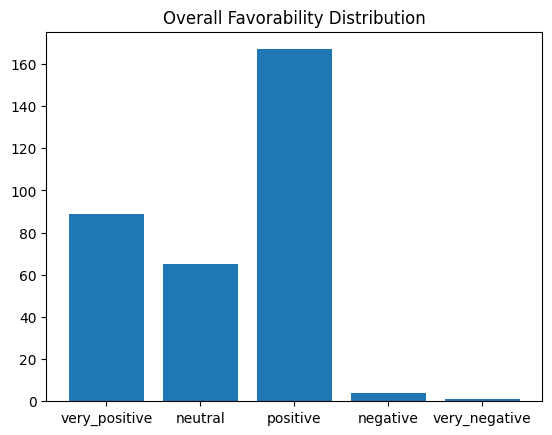

In [189]:
plt.bar(overall_favorability_counts.keys(), overall_favorability_counts.values())
plt.title("Overall Favorability Distribution")